# Richness, species–environment relationships, dominance, and trends

**Aim.** This notebook supports a research manuscript by combining:
- **Species richness** (presence-based and spatially thinned), **by state** and **overall**
- **Species–environment** links: **within-state** (Spearman heatmaps), **overall** (scatter panels + Poisson GLM + coefficient plot)
- **Multivariate associations** between richness / abundance and environmental covariates
- **Relative dominance** (abundance-based community structure within regions)
- **Temporal trends** in summed annual abundance (with explicit sampling caveats)

**Design choices**
- **Spatial thinning:** one observation per **species** per **5 km grid cell** per **stateProvince** (reduces spatial pseudoreplication while retaining multi-species presence per cell).
- **Environment:** continuous covariates are averaged within grid cells on the **thinned** table; land cover is summarized as the modal class. **NDVI** is always read **with** land cover (plots and GLM), because greenness is only meaningful relative to cover type.
- **Trends:** species-level **log-linear** trend in **calendar-year** total abundance (minimum data rules applied).

**Caveats (report in paper)**
- Occurrence counts reflect **detection and effort**, not true population size.
- Yearly sums conflate **ecological change** with **observer effort** and **platform coverage**.
- Correlations and GLMs are **associative**; causal inference needs stronger designs.


## 1. Configuration and imports


In [39]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 40)
RANDOM_SEED = 42


## 2. Resolve data path


In [40]:
CANDIDATE_PATHS = [
    Path("file6.csv"),
    Path("../file6.csv"),
    Path("../../file6.csv"),
    Path("final5.csv"),
    Path("../final5.csv"),
    Path("../../final5.csv"),
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place file6.csv or final5.csv in project root or parent folders.")
print("Using:", DATA_PATH.resolve())


Using: D:\maneesha\sem04\intro_DS\project\0020473-260226173443078\file6.csv


## 3. Load integrated occurrence + environment table

Required core fields: species, coordinates, date, count, region. Environmental columns follow `data_dictionary.md`.


In [41]:
CORE = [
    "verbatimScientificName",
    "stateProvince",
    "individualCount",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
]
ENV_NUM = [
    "avg_rad",
    "NDVI_raw",
    "elevation_meters",
    "Carbon_Mass",
    "Dust_Mass",
    "SO2_Mass",
    "Sulfate_Mass",
    "Sea_Salt_Mass",
    "Total_Aerosol_Extinction",
    "temp_mean",
    "rainfall",
    "wind_mean",
    "humid_mean",
    "shortwave_radiation",
]
ENV_CAT = ["LandCover_Class"]

raw = pd.read_csv(DATA_PATH, low_memory=False)
missing_core = [c for c in CORE if c not in raw.columns]
if missing_core:
    raise ValueError(f"Missing core columns: {missing_core}")

use_cols = [c for c in CORE + ENV_NUM + ENV_CAT if c in raw.columns]
df = raw[use_cols].copy()

df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
for c in ["decimalLatitude", "decimalLongitude", "individualCount"] + [
    x for x in ENV_NUM if x in df.columns
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["stateProvince"] = df["stateProvince"].astype(str).str.strip()
df["verbatimScientificName"] = df["verbatimScientificName"].astype(str).str.strip()

if "NDVI_raw" in df.columns:
    df["NDVI"] = df["NDVI_raw"] / 10000.0
elif "NDVI" in raw.columns:
    df["NDVI"] = pd.to_numeric(raw.loc[df.index, "NDVI"], errors="coerce")

df = df.dropna(
    subset=["verbatimScientificName", "stateProvince", "decimalLatitude", "decimalLongitude", "eventDate"]
)
df["year"] = df["eventDate"].dt.year

ic = df["individualCount"].fillna(1.0).clip(lower=1.0)
df["individualCount"] = ic

print(
    f"Rows: {len(df):,} | States: {df['stateProvince'].nunique()} | Species: {df['verbatimScientificName'].nunique()}"
)


Rows: 1,552,048 | States: 25 | Species: 429


## 4. Reference projection for 5 km grid


In [42]:
LON_REF = float(df["decimalLongitude"].median())
LAT_REF = float(df["decimalLatitude"].median())


def add_planar_grid_km(frame: pd.DataFrame, lon0: float, lat0: float, grid_km: float = 5.0) -> pd.DataFrame:
    out = frame.copy()
    lat = out["decimalLatitude"].to_numpy()
    lon = out["decimalLongitude"].to_numpy()
    lat_rad = np.radians(lat)
    out["x_km"] = (lon - lon0) * 111.320 * np.cos(lat_rad)
    out["y_km"] = (lat - lat0) * 110.574
    out["grid_x"] = np.floor(out["x_km"] / grid_km).astype(int)
    out["grid_y"] = np.floor(out["y_km"] / grid_km).astype(int)
    out["cell_id"] = (
        out["stateProvince"].astype(str) + "|" + out["grid_x"].astype(str) + "_" + out["grid_y"].astype(str)
    )
    return out


df = add_planar_grid_km(df, LON_REF, LAT_REF, 5.0)
print("Grid reference lon, lat:", round(LON_REF, 4), round(LAT_REF, 4))


Grid reference lon, lat: 80.3992 6.8841


## 5. Per-species spatial thinning

Within each **stateProvince × grid cell × species**, retain **one** random record. This limits duplicate visits to the same neighbourhood while allowing multiple species per cell.


In [43]:
def thin_per_species_cell(frame: pd.DataFrame, seed: int = RANDOM_SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    work = frame.copy()
    work["_thin_key"] = (
        work["stateProvince"].astype(str)
        + "|"
        + work["grid_x"].astype(str)
        + "_"
        + work["grid_y"].astype(str)
        + "|"
        + work["verbatimScientificName"].astype(str)
    )
    work["_rand"] = rng.random(len(work))
    th = work.sort_values("_rand").groupby("_thin_key", as_index=False).head(1).drop(columns=["_thin_key", "_rand"])
    return th


df_thin = thin_per_species_cell(df, seed=RANDOM_SEED)
print(f"Before: {len(df):,} | After thin: {len(df_thin):,} | Retained: {len(df_thin)/len(df):.2%}")


Before: 1,552,048 | After thin: 95,608 | Retained: 6.16%


## 6. Grid-cell summaries for analysis


In [44]:
num_for_agg = [
    c
    for c in [
        "NDVI",
        "avg_rad",
        "elevation_meters",
        "temp_mean",
        "rainfall",
        "Total_Aerosol_Extinction",
        "humid_mean",
    ]
    if c in df_thin.columns
]

agg_dict = {"verbatimScientificName": "nunique", "individualCount": "sum"}
for c in num_for_agg:
    agg_dict[c] = "mean"

gcell = df_thin.groupby("cell_id", as_index=False).agg(agg_dict)
gcell = gcell.rename(columns={"verbatimScientificName": "species_richness", "individualCount": "sum_count_thin"})

if "LandCover_Class" in df_thin.columns:
    mode_lc = (
        df_thin.groupby("cell_id")["LandCover_Class"]
        .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
        .rename("LandCover_mode")
    )
    gcell = gcell.merge(mode_lc.reset_index(), on="cell_id", how="left")

for c in num_for_agg:
    if c in gcell.columns:
        gcell = gcell.dropna(subset=[c])

print("Grid cells retained:", len(gcell))
gcell.head(3)


Grid cells retained: 1740


,cell_id,species_richness,sum_count_thin,NDVI,avg_rad,elevation_meters,temp_mean,rainfall,Total_Aerosol_Extinction,humid_mean,LandCover_mode
0,Ampara|14_13,19,707.0,0.766400,0.440000,117.000000,28.670000,3.080000,0.129025,73.990000,9
1,Ampara|14_17,13,17.0,0.806900,2.186154,91.230769,27.436154,1.266154,0.170013,80.355385,14
2,Ampara|15_15,47,156.0,0.724074,0.452553,104.553191,27.782553,6.318723,0.144869,80.517872,9


## 6b. Richness in each `stateProvince`

Two views:
- **Mean species richness per 5 km cell** (from thinned records) — comparable across states of different sizes.
- **Total species pool** — distinct species observed in that state on the thinned table (upper bound limited by sampling).


In [45]:
gcell["stateProvince"] = gcell["cell_id"].str.split("|").str[0]

species_pool = df_thin.groupby("stateProvince")["verbatimScientificName"].nunique().rename("species_pool_total")

state_summary = (
    gcell.groupby("stateProvince", as_index=True)
    .agg(
        n_grid_cells=("cell_id", "count"),
        mean_richness_per_cell=("species_richness", "mean"),
        median_richness=("species_richness", "median"),
    )
    .join(species_pool, how="left")
    .sort_values("mean_richness_per_cell", ascending=False)
)
state_summary.round(2).head(15)


,n_grid_cells,mean_richness_per_cell,median_richness,species_pool_total
stateProvince,,,,
Colombo,39,84.77,78.0,280
Hambantota,89,80.96,64.0,329
Mannar,50,80.74,60.5,304
Gampaha,68,69.72,72.0,303
Matara,57,68.95,56.0,299
Matale,68,64.49,54.5,268
Monaragala,100,59.85,46.5,281
Puttalam,101,59.25,51.0,283
Kandy,71,58.51,55.0,240


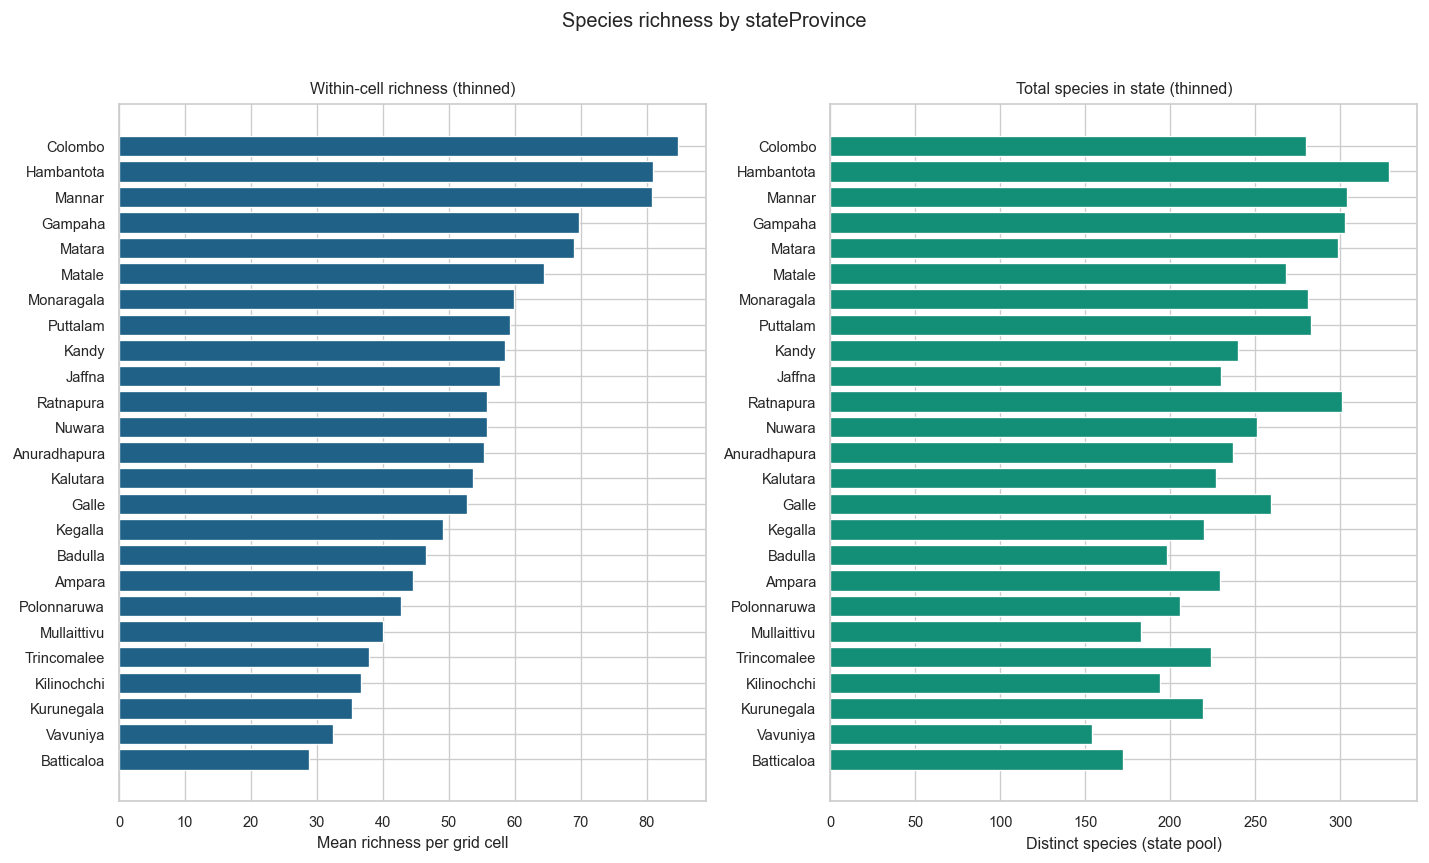

In [46]:
ss = state_summary.sort_values("mean_richness_per_cell", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12, max(5, 0.28 * len(ss))))
axes[0].barh(ss.index.astype(str), ss["mean_richness_per_cell"], color="#1f6187")
axes[0].set_xlabel("Mean richness per grid cell")
axes[0].set_title("Within-cell richness (thinned)")
axes[1].barh(ss.index.astype(str), ss["species_pool_total"], color="#148f77")
axes[1].set_xlabel("Distinct species (state pool)")
axes[1].set_title("Total species in state (thinned)")
plt.suptitle("Species richness by stateProvince", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


## 6c. Within each state: how grid-cell richness relates to environmental features

For every **state** with enough grid cells (**≥ `MIN_CELLS_STATE`**), we compute **Spearman** correlations between **cell richness** and each **mean environmental** variable **within that state only**.  
This shows whether associations are **consistent** across regions or **flip sign** (context-dependent).


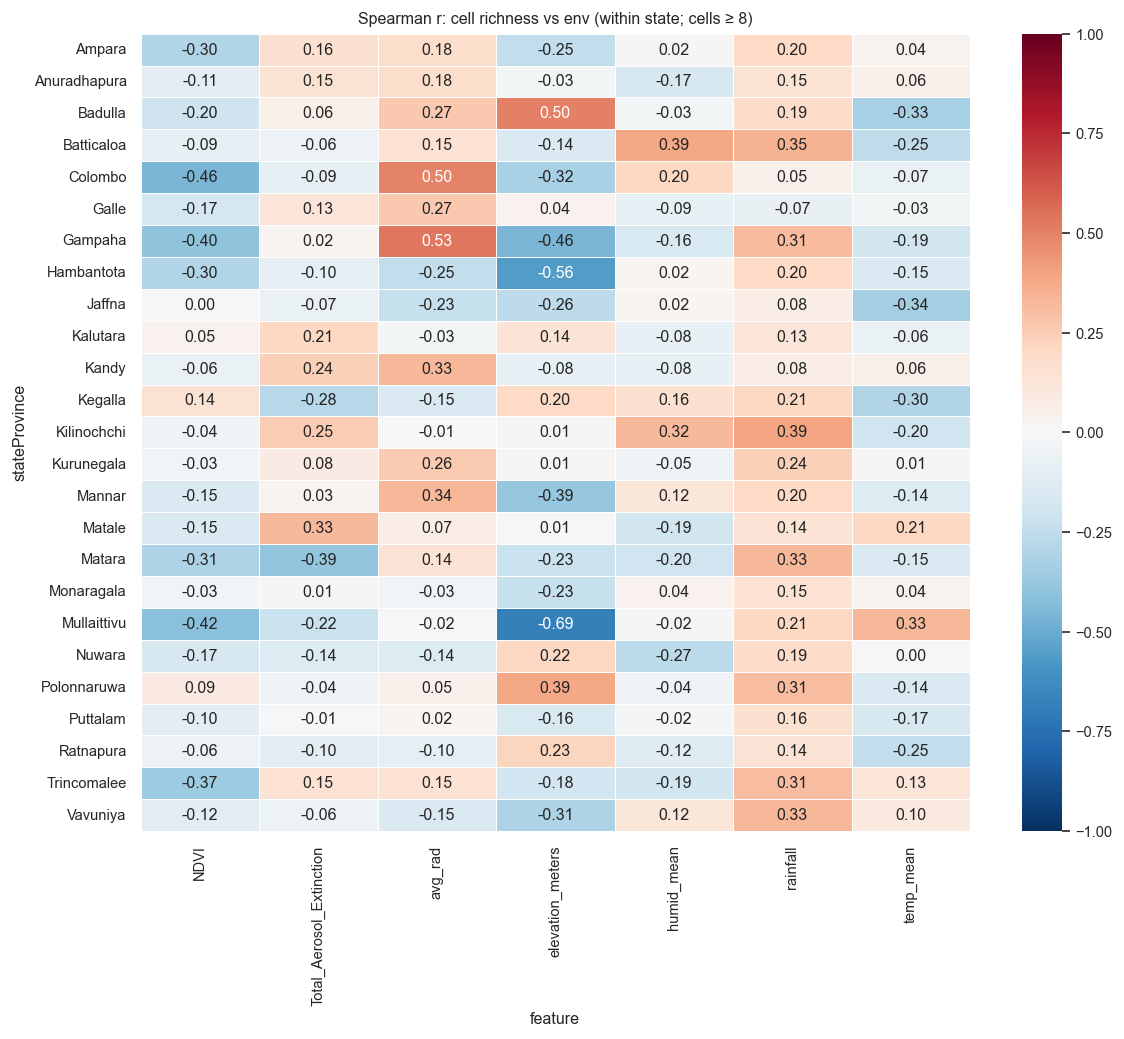

In [47]:
MIN_CELLS_STATE = 8
feat_cols_state = [c for c in num_for_agg if c in gcell.columns]

rows_sp = []
for st, sub in gcell.groupby("stateProvince"):
    if len(sub) < MIN_CELLS_STATE:
        continue
    for f in feat_cols_state:
        r, p = stats.spearmanr(sub["species_richness"], sub[f], nan_policy="omit")
        rows_sp.append({"stateProvince": st, "feature": f, "spearman_r": r, "p": p, "n_cells": len(sub)})

corr_state_long = pd.DataFrame(rows_sp)
if len(corr_state_long):
    corr_state_mat = corr_state_long.pivot(index="stateProvince", columns="feature", values="spearman_r")
    h = max(6, 0.35 * len(corr_state_mat))
    fig, ax = plt.subplots(figsize=(10, h))
    sns.heatmap(
        corr_state_mat,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax,
        linewidths=0.5,
    )
    ax.set_title(
        f"Spearman r: cell richness vs env (within state; cells ≥ {MIN_CELLS_STATE})"
    )
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for per-state correlations.")


## 6d. Overall (all grid cells): richness vs key features

**NDVI** is interpreted **together with modal land cover** (`LandCover_mode` per cell): greenness differs systematically among cover types (forest vs crop vs urban), so the same NDVI value does not mean the same habitat.  
- **First figure:** NDVI vs richness with **separate OLS lines per land-cover class** (top classes by cell count).  
- **Second figure:** other continuous predictors (NDVI not duplicated here); pooled scatters match the multivariate GLM in §8 (which includes **NDVI + land cover**).


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


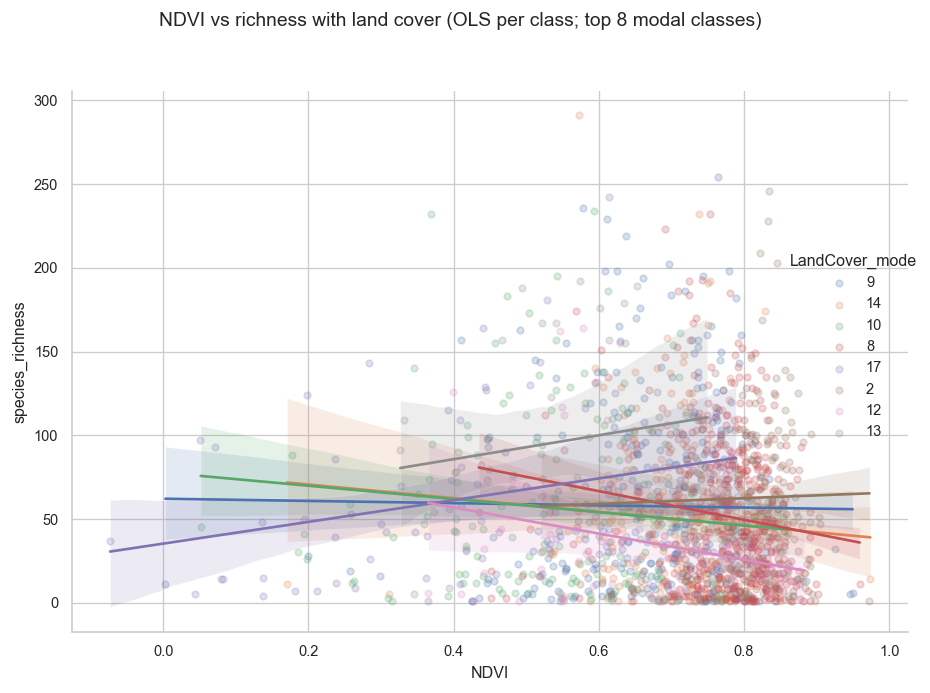

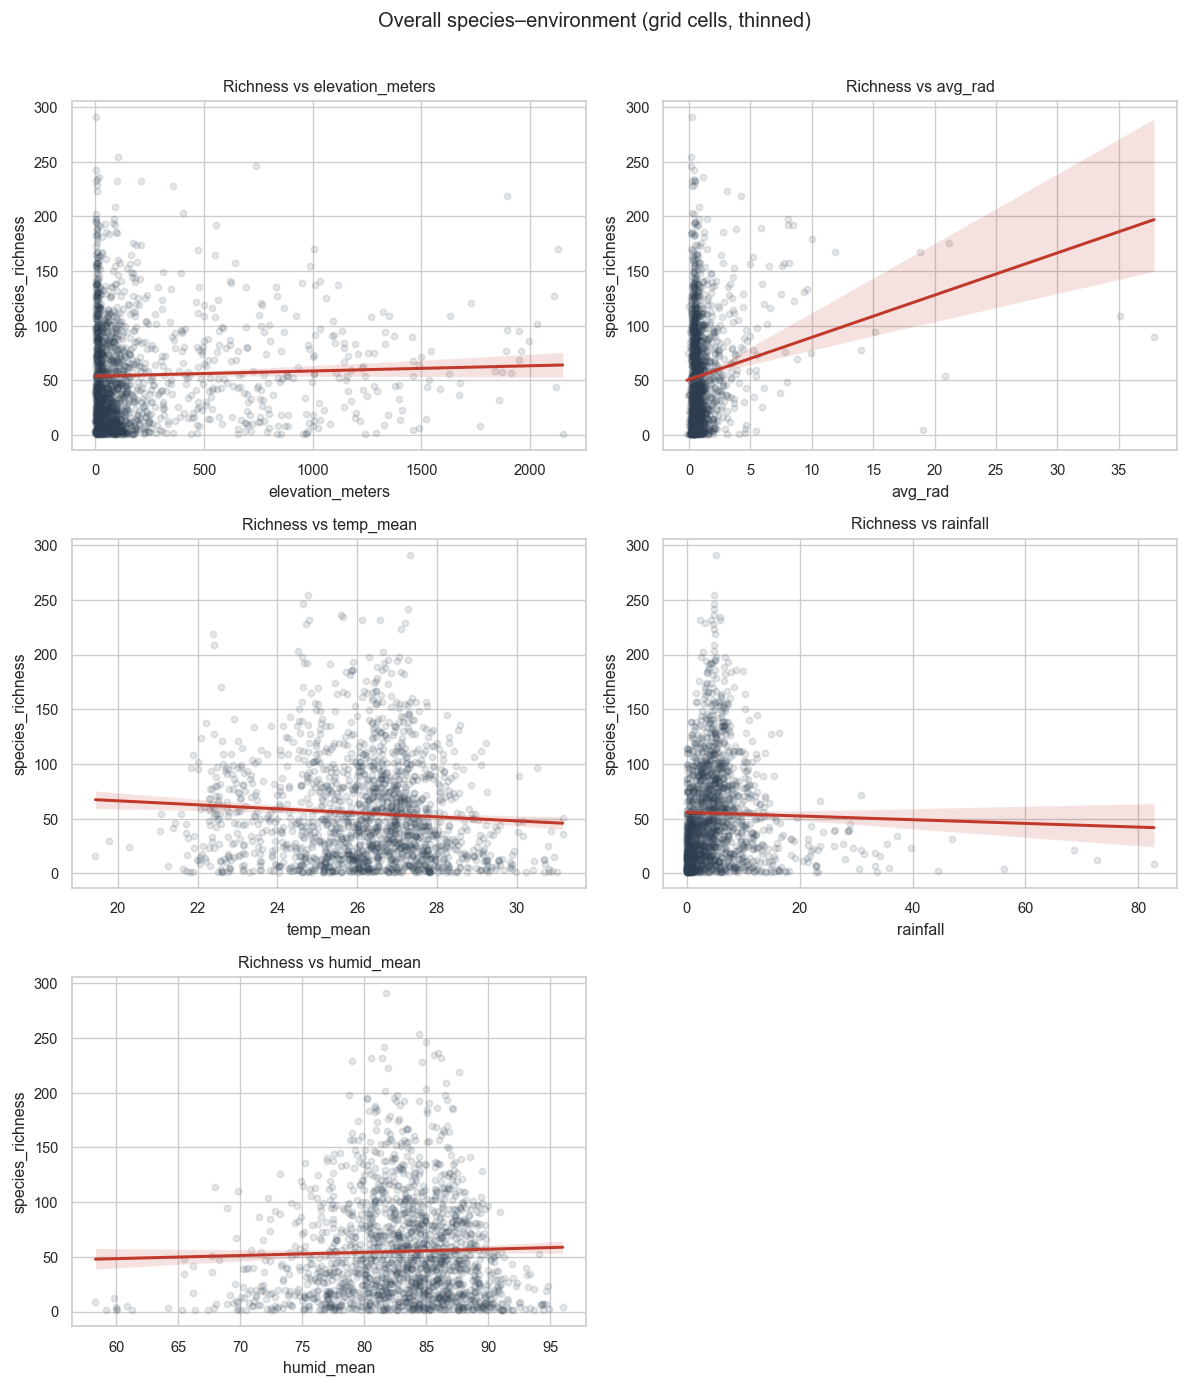

In [48]:
# --- NDVI + modal land cover (vegetation type frames how greenness should be read) ---
if "LandCover_mode" in gcell.columns and "NDVI" in gcell.columns:
    vc_lc = gcell["LandCover_mode"].value_counts()
    top_k = 8
    keep_lc = vc_lc.nlargest(top_k).index
    g_lc = gcell[gcell["LandCover_mode"].isin(keep_lc)].copy()
    g_lc["LandCover_mode"] = g_lc["LandCover_mode"].astype(str)
    g = sns.lmplot(
        data=g_lc,
        x="NDVI",
        y="species_richness",
        hue="LandCover_mode",
        scatter_kws={"alpha": 0.22, "s": 16},
        height=5.5,
        aspect=1.2,
        legend_out=True,
        line_kws={"linewidth": 1.6},
    )
    g.fig.suptitle(
        f"NDVI vs richness with land cover (OLS per class; top {top_k} modal classes)",
        y=1.04,
    )
    plt.tight_layout()
    plt.show()
else:
    print("LandCover_mode or NDVI missing; cannot build NDVI–land cover figure.")

# --- Other continuous predictors (NDVI shown above with land cover) ---
panel_feats = [
    c
    for c in ["elevation_meters", "avg_rad", "temp_mean", "rainfall", "humid_mean"]
    if c in gcell.columns
][:6]
n_p = len(panel_feats)
if n_p:
    n_cols = 2
    n_rows = int(np.ceil(n_p / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.8 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for i, feat in enumerate(panel_feats):
        sns.regplot(
            data=gcell,
            x=feat,
            y="species_richness",
            scatter_kws={"alpha": 0.12, "s": 14, "color": "#2c3e50"},
            line_kws={"color": "#c0392b"},
            ax=axes[i],
            lowess=False,
        )
        axes[i].set_title(f"Richness vs {feat}")
    for j in range(len(panel_feats), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Overall species–environment (grid cells, thinned)", y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()


## 6e. NDVI vs richness **by modal land cover** (facets)

Separate panel for each of the **six most common** `LandCover_mode` classes: same NDVI axis, but **habitat context** is fixed within each facet.  
Compare to §6d (lines overlaid by class on one plot).


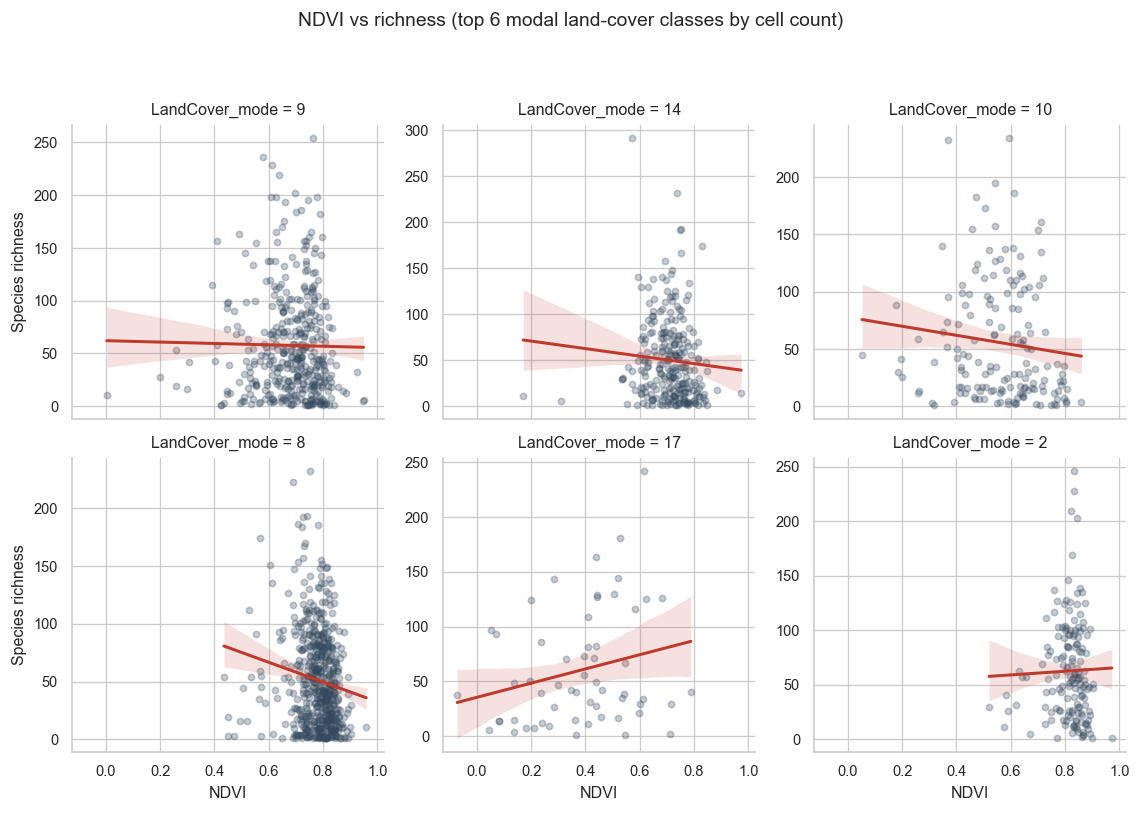

In [49]:
if "LandCover_mode" in gcell.columns and "NDVI" in gcell.columns:
    top6_lc = gcell.groupby("LandCover_mode").size().nlargest(6).index
    sub = gcell[gcell["LandCover_mode"].isin(top6_lc)].copy()
    sub["LandCover_mode"] = sub["LandCover_mode"].astype(str)
    g = sns.FacetGrid(
        sub,
        col="LandCover_mode",
        col_wrap=3,
        height=3.2,
        aspect=1.0,
        sharey=False,
        sharex=True,
    )
    g.map(
        sns.regplot,
        "NDVI",
        "species_richness",
        scatter_kws={"alpha": 0.28, "s": 14, "color": "#34495e"},
        line_kws={"color": "#c0392b"},
    )
    g.set_axis_labels("NDVI", "Species richness")
    g.fig.suptitle("NDVI vs richness (top 6 modal land-cover classes by cell count)", y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("LandCover_mode or NDVI missing; skip faceted plot.")


## 7. Richness vs environment (exploratory)

Pairwise **Spearman** correlations (marginal associations). **NDVI** here is **not** conditioned on land cover; for a **joint** NDVI + land-cover view see §6d–6e and §8.


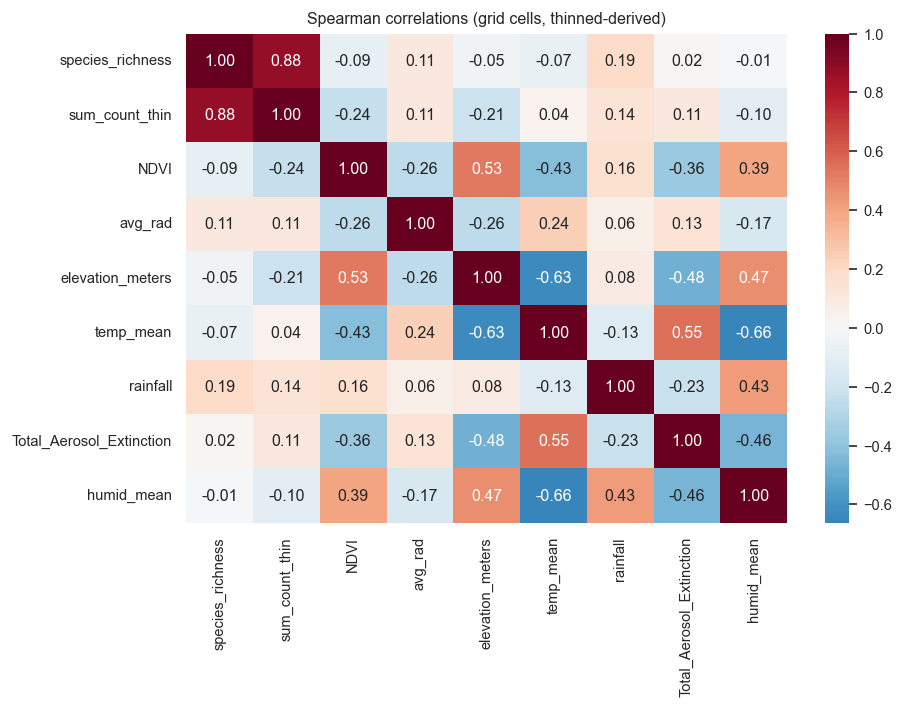

In [50]:
corr_cols = [c for c in ["species_richness", "sum_count_thin"] + num_for_agg if c in gcell.columns]
cmat = gcell[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cmat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Spearman correlations (grid cells, thinned-derived)")
plt.tight_layout()
plt.show()


## 8. GLM: species richness ~ NDVI + land cover + environment (Poisson)

**NDVI** and **modal land cover** enter together: `C(LandCover_mode)` absorbs baseline differences among cover types; the **NDVI** coefficient is then **adjusted** for those types (additive model).  
Rare land-cover classes (fewer than `MIN_LC_CELLS` grid cells) are dropped before fitting.


In [51]:
MIN_LC_CELLS = 25
cont_terms = [
    c
    for c in [
        "NDVI",
        "avg_rad",
        "elevation_meters",
        "temp_mean",
        "rainfall",
        "Total_Aerosol_Extinction",
    ]
    if c in gcell.columns
]

g_fit = gcell.copy()
use_lc = False
if "LandCover_mode" in g_fit.columns and "NDVI" in g_fit.columns:
    g_fit = g_fit.dropna(subset=["LandCover_mode", "NDVI"])
    vc = g_fit["LandCover_mode"].value_counts()
    keep_lc = vc[vc >= MIN_LC_CELLS].index
    if len(keep_lc) >= 2:
        g_fit = g_fit[g_fit["LandCover_mode"].isin(keep_lc)]
        use_lc = True
    else:
        print("Warning: too few cells per land-cover class; fitting without C(LandCover_mode).")
elif "LandCover_mode" in g_fit.columns:
    print("Warning: NDVI missing; cannot pair NDVI with land cover in GLM.")

parts = []
if "NDVI" in cont_terms:
    parts.append("NDVI")
if use_lc:
    parts.append("C(LandCover_mode)")
for c in cont_terms:
    if c != "NDVI":
        parts.append(c)
rhs = " + ".join(parts)

need = ["species_richness"] + [c for c in cont_terms if c in g_fit.columns]
if use_lc and "LandCover_mode" in g_fit.columns:
    need.append("LandCover_mode")
g_fit = g_fit.dropna(subset=[c for c in need if c in g_fit.columns])

formula = "species_richness ~ " + rhs
print("Formula:", formula)
print("Rows used:", len(g_fit))

pois = None
try:
    pois = smf.glm(formula, data=g_fit, family=families.Poisson()).fit(cov_type="HC1")
    print(pois.summary())
except Exception as exc:
    pois = None
    print("GLM could not be fit (check collinearity / sample size):", exc)


Formula: species_richness ~ NDVI + C(LandCover_mode) + avg_rad + elevation_meters + temp_mean + rainfall + Total_Aerosol_Extinction
Rows used: 1736
                 Generalized Linear Model Regression Results                  
Dep. Variable:       species_richness   No. Observations:                 1736
Model:                            GLM   Df Residuals:                     1721
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36869.
Date:                Mon, 06 Apr 2026   Deviance:                       64476.
Time:                        20:26:26   Pearson chi2:                 6.63e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.8035
Covariance Type:                  HC1                                         
                               coef    std err          z     

## 8a. Overall model: coefficient forest plot (log link)

Poisson GLM coefficients on the **log** scale: $\exp(\beta)$ is a **rate ratio** for richness when the predictor increases by one unit.  
Land-cover levels appear as **dummy coefficients** (reference category omitted). **NDVI** in this plot is the coefficient from the **NDVI + land cover + climate** model.  
Error bars use **HC1** robust intervals from the fitted model.


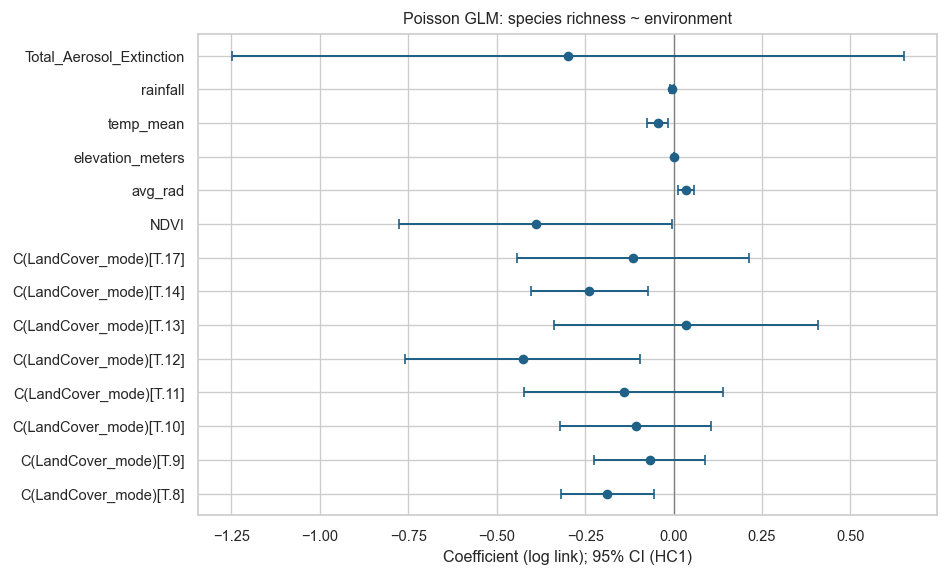

In [52]:
if pois is not None:
    names = [n for n in pois.params.index if n not in ("const", "Intercept")]
    coef = pois.params.loc[names]
    ci = pois.conf_int().loc[names]
    lo, hi = ci[0], ci[1]
    y_pos = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(names))))
    ax.axvline(0, color="gray", lw=0.8)
    xerr = np.vstack([coef.values - lo.values, hi.values - coef.values])
    ax.errorbar(coef.values, y_pos, xerr=xerr, fmt="o", capsize=3, color="#1f6187")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names)
    ax.set_xlabel("Coefficient (log link); 95% CI (HC1)")
    ax.set_title("Poisson GLM: species richness ~ environment")
    plt.tight_layout()
    plt.show()
else:
    print("Fit GLM in the previous cell to plot coefficients.")


## 8b. Richness vs modal land cover (Kruskal–Wallis)

Tests whether **median** grid-cell richness differs across **modal** `LandCover_Class` (coarse check; land cover is not independent of geography).


In [53]:
if "LandCover_mode" in gcell.columns and gcell["LandCover_mode"].notna().any():
    groups = [g["species_richness"].values for _, g in gcell.groupby("LandCover_mode") if len(g) >= 5]
    if len(groups) >= 2:
        H, p_kw = stats.kruskal(*groups)
        print(f"Kruskal–Wallis H = {H:.3f}, p = {p_kw:.4g} ({len(groups)} land-cover classes with n>=5 cells)")
    else:
        print("Not enough cells per land-cover class for Kruskal–Wallis.")
else:
    print("LandCover_mode not available; skip.")


Kruskal–Wallis H = 36.755, p = 1.277e-05 (9 land-cover classes with n>=5 cells)


## 9. Relative dominance by state (full data)

Uses **all** records to quantify how concentrated abundance is within each **stateProvince**.
- **Berger–Parker** D: maximum proportional abundance.
- **Simpson dominance** sum p_i^2 (complement is Simpson diversity).
- **Shannon** H', **Pielou evenness** J = H' / ln(S).


In [54]:
def dominance_metrics(counts: pd.Series) -> pd.Series:
    c = counts.astype(float).clip(lower=0)
    tot = c.sum()
    if tot <= 0:
        return pd.Series(
            {
                "n_records": 0,
                "S": 0,
                "Berger_Parker": np.nan,
                "Simpson_D": np.nan,
                "Shannon_H": np.nan,
                "Pielou_J": np.nan,
            }
        )
    p = c / tot
    S = int((p > 0).sum())
    bp = float(p.max())
    simp = float((p**2).sum())
    sh = float(-(p[p > 0] * np.log(p[p > 0])).sum())
    j = sh / np.log(S) if S > 1 else np.nan
    return pd.Series(
        {
            "n_records": int(c.sum()),
            "S": S,
            "Berger_Parker": bp,
            "Simpson_D": simp,
            "Shannon_H": sh,
            "Pielou_J": j,
        }
    )


sp_totals = df.groupby(["stateProvince", "verbatimScientificName"], as_index=False)["individualCount"].sum()
_dom_rows = []
for state, g in sp_totals.groupby("stateProvince"):
    m = dominance_metrics(g.set_index("verbatimScientificName")["individualCount"])
    m = m.to_dict()
    m["stateProvince"] = state
    _dom_rows.append(m)
dom_state = pd.DataFrame(_dom_rows)
dom_state = dom_state.sort_values("Shannon_H", ascending=False)
dom_state.head(12)


,n_records,S,Berger_Parker,Simpson_D,Shannon_H,Pielou_J,stateProvince
15,195216.0,268.0,0.093466,0.023128,4.398401,0.786695,Matale
1,219948.0,237.0,0.070539,0.021031,4.375878,0.800261,Anuradhapura
17,407066.0,281.0,0.090103,0.024761,4.324737,0.767021,Monaragala
21,308307.0,283.0,0.058500,0.022567,4.293066,0.760447,Puttalam
11,168361.0,220.0,0.054359,0.021834,4.278685,0.793285,Kegalla
2,121542.0,198.0,0.061172,0.021058,4.262014,0.805938,Badulla
7,1477020.0,329.0,0.072813,0.024497,4.256805,0.734431,Hambantota
0,51170.0,229.0,0.072953,0.026300,4.203807,0.773651,Ampara
10,160258.0,240.0,0.082554,0.029282,4.129703,0.753507,Kandy
24,9060.0,154.0,0.100331,0.028968,4.124700,0.818888,Vavuniya


## 10. Plot dominance across states


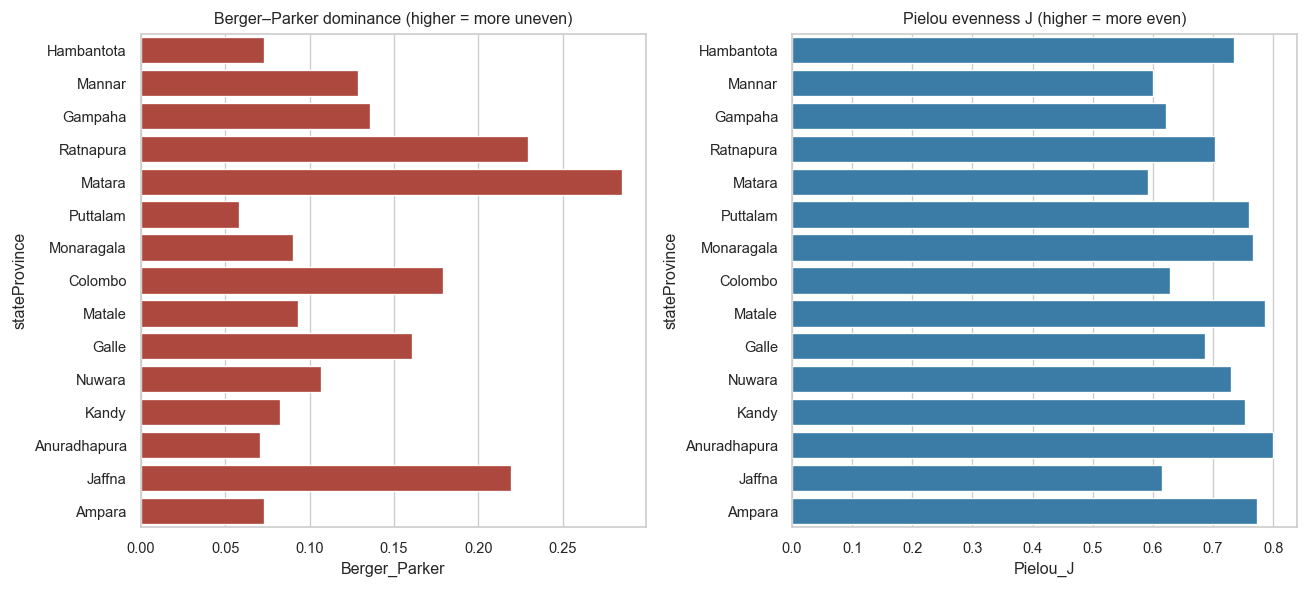

In [55]:
top_n = 15
sub = dom_state.nlargest(top_n, "S")
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.barplot(data=sub, y="stateProvince", x="Berger_Parker", ax=axes[0], color="#c0392b")
axes[0].set_title("Berger–Parker dominance (higher = more uneven)")
sns.barplot(data=sub, y="stateProvince", x="Pielou_J", ax=axes[1], color="#2980b9")
axes[1].set_title("Pielou evenness J (higher = more even)")
plt.tight_layout()
plt.show()


## 11. Population trends — annual abundance by species

For each species with sufficient history, fit **log1p(total annual count) ~ year** (OLS).
Coefficients are **heuristic indices of change**, not verified population trajectories.


In [56]:
annual = (
    df.groupby(["verbatimScientificName", "year"], as_index=False)["individualCount"]
    .sum()
    .rename(columns={"individualCount": "annual_abund"})
)
species_years = annual.groupby("verbatimScientificName")["year"].nunique()
MIN_YEARS = 8
MIN_TOTAL = 500
tot_per_sp = annual.groupby("verbatimScientificName")["annual_abund"].sum()
cand = species_years[species_years >= MIN_YEARS].index.intersection(tot_per_sp[tot_per_sp >= MIN_TOTAL].index)

rows = []
for sp in cand:
    sub = annual[annual["verbatimScientificName"] == sp].copy()
    sub["log1p_abund"] = np.log1p(sub["annual_abund"])
    yvec = sub["log1p_abund"].values
    xvec = sub["year"].values
    slope, intercept, r, p, se = stats.linregress(xvec, yvec)
    rows.append(
        {
            "species": sp,
            "n_years": len(sub),
            "slope_per_year": slope,
            "p_value": p,
            "r_squared": r**2,
        }
    )

trend_df = pd.DataFrame(rows)
if len(trend_df):
    trend_df = trend_df.sort_values("slope_per_year")
    _, trend_df["q_bh"], _, _ = multipletests(trend_df["p_value"], method="fdr_bh")
print("Species evaluated:", len(trend_df))
trend_df.head(8)


Species evaluated: 283


,species,n_years,slope_per_year,p_value,r_squared,q_bh
99,Elanus caeruleus,11,0.087982,0.005756,0.590056,0.006123
204,Phalaropus lobatus,11,0.099077,0.373984,0.088611,0.373984
173,Myophonus blighi,11,0.113597,0.001415,0.695668,0.001634
100,Elaphrornis palliseri,11,0.117974,0.012013,0.522089,0.012407
35,Botaurus flavicollis,11,0.124289,0.000627,0.744528,0.000775
200,Phaenicophaeus pyrrhocephalus,11,0.131259,0.000740,0.735185,0.000892
117,Geokichla wardii,11,0.133074,0.015155,0.498643,0.015539
154,Lonchura kelaarti,11,0.134038,0.000166,0.808529,0.000233


## 12. Strongest increasing / decreasing trends


In [57]:
if len(trend_df):
    inc = trend_df.nlargest(8, "slope_per_year")
    dec = trend_df.nsmallest(8, "slope_per_year")
    print("Top increases:\n", inc[["species", "slope_per_year", "p_value", "q_bh"]])
    print("\nTop decreases:\n", dec[["species", "slope_per_year", "p_value", "q_bh"]])
else:
    print("No species passed MIN_YEARS / MIN_TOTAL filters.")


Top increases:
                       species  slope_per_year   p_value      q_bh
182    Onychoprion anaethetus        0.798348  0.014300  0.014716
169  Motacilla tschutschensis        0.740126  0.009133  0.009468
168           Motacilla flava        0.647689  0.003872  0.004166
211      Plegadis falcinellus        0.587654  0.000001  0.000005
47        Calidris temminckii        0.576200  0.001047  0.001235
43        Calidris ferruginea        0.571664  0.000299  0.000392
119       Glareola maldivarum        0.570770  0.006839  0.007142
147              Larus fuscus        0.564712  0.005856  0.006183

Top decreases:
                            species  slope_per_year   p_value      q_bh
99                Elanus caeruleus        0.087982  0.005756  0.006123
204             Phalaropus lobatus        0.099077  0.373984  0.373984
173               Myophonus blighi        0.113597  0.001415  0.001634
100          Elaphrornis palliseri        0.117974  0.012013  0.012407
35            Bota

## 13. Example species: annual trajectory plots


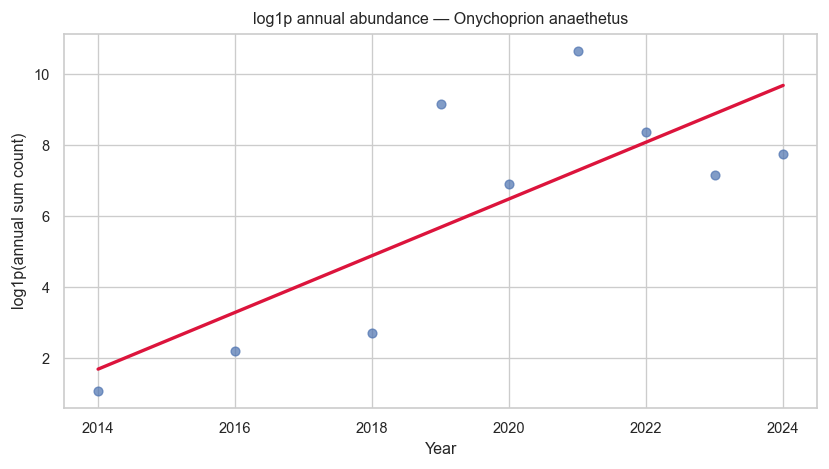

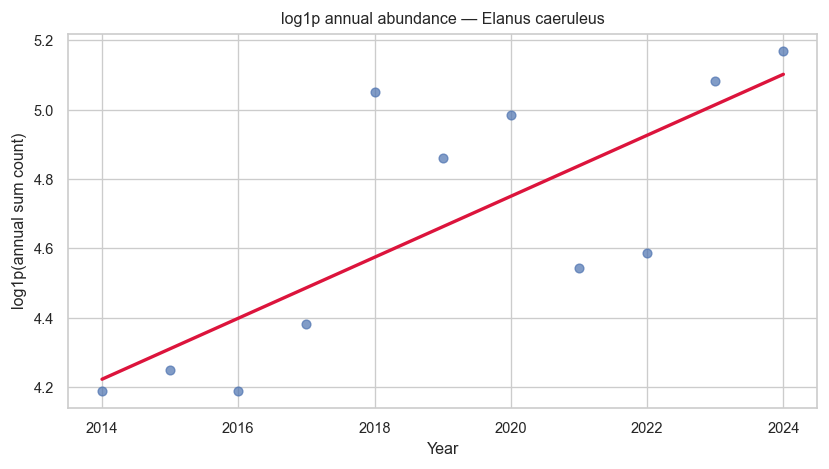

In [58]:
def plot_species_trend(species_name: str):
    sub = annual[annual["verbatimScientificName"] == species_name]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(sub["year"], np.log1p(sub["annual_abund"]), alpha=0.7, s=28)
    z = np.polyfit(sub["year"], np.log1p(sub["annual_abund"].values), 1)
    ax.plot(sorted(sub["year"]), np.poly1d(z)(sorted(sub["year"])), color="crimson", lw=2)
    ax.set_title(f"log1p annual abundance — {species_name}")
    ax.set_xlabel("Year")
    ax.set_ylabel("log1p(annual sum count)")
    plt.tight_layout()
    plt.show()


if len(trend_df):
    mx = trend_df.loc[trend_df["slope_per_year"].idxmax(), "species"]
    mn = trend_df.loc[trend_df["slope_per_year"].idxmin(), "species"]
    plot_species_trend(mx)
    plot_species_trend(mn)


## 13b. National annual total abundance (sampling context)

Summed **individualCount** per year across all records — useful as a **relative effort** proxy when interpreting species trends.


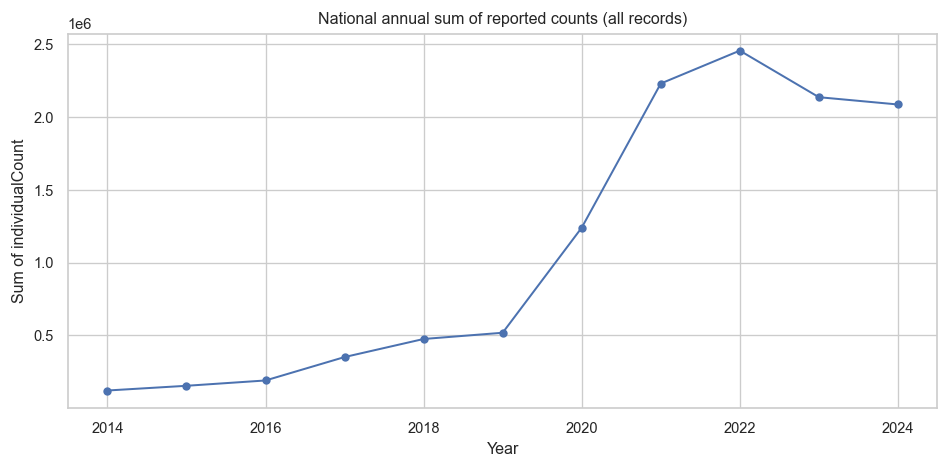

In [59]:
nat = df.groupby("year", as_index=False)["individualCount"].sum().rename(columns={"individualCount": "total_count"})
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(nat["year"], nat["total_count"], marker="o", ms=4)
ax.set_title("National annual sum of reported counts (all records)")
ax.set_xlabel("Year")
ax.set_ylabel("Sum of individualCount")
plt.tight_layout()
plt.show()


## 14. Export tables (optional)

Uncomment to write CSV summaries next to this notebook.


In [60]:
# out_dir = Path(".")
# gcell.to_csv(out_dir / "gridcell_richness_env.csv", index=False)
# dom_state.to_csv(out_dir / "state_dominance_metrics.csv", index=False)
# trend_df.to_csv(out_dir / "species_annual_trend_slopes.csv", index=False)
# print("Saved.")


---
**Manuscript snippets**
- **Methods:** per-species 5 km thinning within state; grid-cell aggregation; Spearman screening; Poisson GLM with robust (HC1) SE; dominance indices on state-level summed counts; species-level log-linear trends on annual sums with Benjamini–Hochberg FDR.
- **Limitations:** effort confounding for trends; associative (non-causal) environment models.
